# Data science taster module 
## Data science for science and technology policy

## Analysis task - Ocean science research investigation

This is a Jupyter notebook. Here, it is used to create, run and visualise python computer code to analyse the ocean science dataset.

Each cell in the notebook will carry out the functions within it. If requested (such as displaying a graph), the output of the cell will be displayed directly below it.

This setup allows easy de-bugging (error fixing) and a clear history of what has been coded.  

For the analysis, inputs can be changed (such as the country of interest) in the cells as needed. Where this can be done will be highlighted in the appropriate cells.

Run each cell one at a time by holding down the shift and return key simultaneously or by pressing the 'play' button in the icon bar above.

## Motivation and questions

You work for the Natural Sciences and Engineering Council of Canada (NSERC)

NSERC are interested in allocating more funding for research pertaining to UN Sustainable Development Goal 14 - Life below water - particularly in regard to oceans

For this, they must first understand Canada's current ocean science research output.

Your boss has procured a dataset for you to analyze and wants to know:
- Canada's overall ocean science research output.
- How Canada's output compares to three trade partners (Australia, Norway and Japan) and how this has changed over time.
- In what ocean does Canada have greater output than these comparators?
- And where does Canada rank in this ocean in terms of output?
- How much collaboration does Canada do with these, and other, partners?



## Preamble

### This installs the relevant programming libraries and tools needed 

In [2]:
import pandas as pd
import csv
import sys
import numpy as np
import dataframe_image as dfi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
%matplotlib inline  

#pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)

print('python :',sys.version)
print('numpy: ',np.__version__)
print('pandas: ',pd.__version__)
print('matplotlib: ',pd.__version__)
print('seaborn: ',sns.__version__)

/Users/RoPotter/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


python : 3.9.6 (default, Mar  6 2026, 16:22:44) 
[Clang 21.0.0 (clang-2100.0.123.102)]
numpy:  2.0.2
pandas:  2.3.3
matplotlib:  2.3.3
seaborn:  0.13.2


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker
import math

plt.rcParams["font.family"] = "Arial"
plt.rcParams['figure.constrained_layout.use'] = False
plt.rcParams['axes.formatter.limits'] = (-5,5)
sns.set(rc={'legend.frameon':False})
sns.set_style("whitegrid", {"axes.edgecolor": ".0", "axes.facecolor":"none"})

labelsize = 12
rcParams['xtick.labelsize'] = labelsize
rcParams['ytick.labelsize'] = labelsize 
rcParams['figure.titlesize'] = 24
plt.rc('legend',fontsize=12) # using a size in points
plt.rc('axes', labelsize=labelsize)    # fontsize of the x and y labels

%matplotlib inline 

In [4]:
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout
from pyvis import network as net

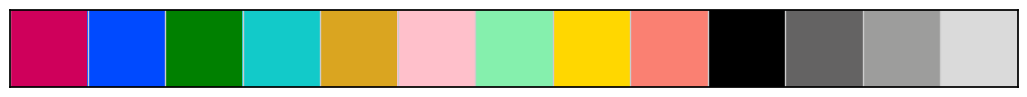

In [5]:
isi_colour = [
"#CF005B" 
,"#004AFF"
,'green'    
,"#12CAC9"
,"goldenrod"
,'pink'
,"#85F0AD"
,'gold'
,'salmon'
,'#000000'
,"#646363" 
,"#9D9D9C" 
,"#DADADA"]

sns.set_palette(isi_colour)
sns.palplot(sns.color_palette())

### Open dataset and find some basic statistics about it

### e.g. How many papers?, What are the publication years?

In [6]:
dataset = pd.read_excel('module_dataset.xlsx')
dataset.head()

,ut,doi,pub year,title,journal,keywords,citation count,ocean,Country,Country unique,international
0,WOS:000594534000001,10.3897/zse.96.59448,2020,survey of stenomelania fischer 1885 (cerithioi...,ZOOSYST EVOL,cerithioidea|haplorchis taichui|loxogenoides b...,1,indian,THAILAND,2,Y
1,WOS:000594534000001,10.3897/zse.96.59448,2020,survey of stenomelania fischer 1885 (cerithioi...,ZOOSYST EVOL,cerithioidea|haplorchis taichui|loxogenoides b...,1,indian,GERMANY,2,Y
2,WOS:000598020000013,10.1017/S0025315420000880,2020,redescription and molecular characterization o...,J MAR BIOL ASSOC UK,crenidens macracanthus|c|indicus|sparidae|rede...,0,indian,INDIA,1,N
3,WOS:000598020000014,10.1017/S0025315420000922,2020,reproductive seasonality and the gonadal matur...,J MAR BIOL ASSOC UK,bay of bengal|fecundity|gsi|histology|pampus a...,3,indian,INDIA,3,Y
4,WOS:000598020000014,10.1017/S0025315420000922,2020,reproductive seasonality and the gonadal matur...,J MAR BIOL ASSOC UK,bay of bengal|fecundity|gsi|histology|pampus a...,3,indian,BANGLADESH,3,Y


In [7]:
dataset['ut'].nunique()

104220

In [8]:
dataset['ocean'].unique()

array(['indian', 'arctic', 'southern', 'atlantic', 'pacific'],
      dtype=object)

In [9]:
dataset['pub year'].unique()

array([2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010,
       2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000])

### Is Canada one of the top producing countries?

In [10]:
country_list_by_count = dataset.groupby(['Country'])['ut'].nunique().sort_values(ascending=False).reset_index()
country_list_by_count.head(20)

,Country,ut
0,USA,34512
1,CHINA,12932
2,UNITED KINGDOM,10292
3,GERMANY,7845
4,FRANCE,7841
5,CANADA,7254
6,JAPAN,6828
7,NORWAY,6073
8,AUSTRALIA,5848
9,BRAZIL,4979


### How does Canada's output change over time and how does this compare to the three trade partners?

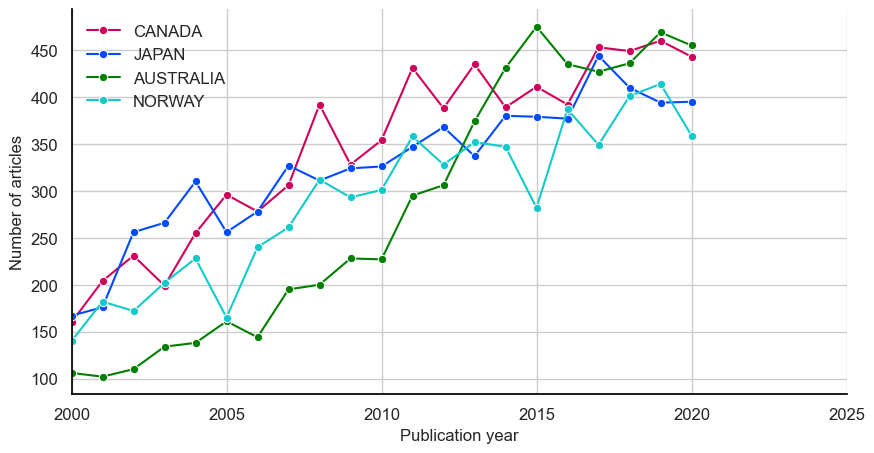

In [23]:
plt.figure(figsize=(10,5))

for country in ['CANADA','JAPAN','AUSTRALIA','NORWAY']:
    linegraph_data = dataset[(dataset['Country']==country)]
    linegraph_data = linegraph_data.groupby(['pub year'])['ut'].nunique().reset_index()
    
    ax = sns.lineplot(x='pub year',y='ut',data=linegraph_data,marker='o',label=country,legend=True)
    sns.despine(top=True, right=True, left=False, bottom=False)
    plt.ylabel ('Number of articles')
    plt.xlabel('Publication year')
    plt.xlim(2000,2025)
    #plt.ylim(0,2500)

plt.show()

### What is the distrubtion of Canadian research output by ocean?

In [10]:
dataset[dataset['Country']=='CANADA'].groupby(['ocean'])['ut'].nunique()

ocean
arctic       981
atlantic    4323
indian       193
pacific     1982
southern     159
Name: ut, dtype: int64

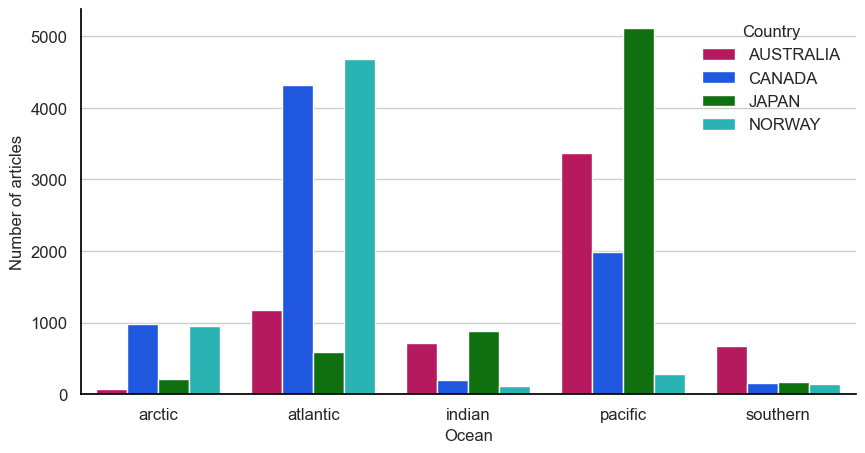

In [11]:
plt.figure(figsize=(10,5))

barplot_data = dataset[dataset['Country'].isin(['CANADA','JAPAN','AUSTRALIA','NORWAY'])]
barplot_data = barplot_data.groupby(['Country','ocean'])['ut'].nunique().reset_index()

ax = sns.barplot(data=barplot_data,x='ocean',y='ut',hue='Country',)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.ylabel ('Number of articles')
plt.xlabel('Ocean')

plt.show()

In [12]:
barplot_data

,Country,ocean,ut
0,AUSTRALIA,arctic,71
1,AUSTRALIA,atlantic,1175
2,AUSTRALIA,indian,717
3,AUSTRALIA,pacific,3372
4,AUSTRALIA,southern,670
5,CANADA,arctic,981
6,CANADA,atlantic,4323
7,CANADA,indian,193
8,CANADA,pacific,1982
9,CANADA,southern,159


### What is the percentage of papers that Canada publishes?

In [13]:
ocean_total_papers = dataset.groupby(['ocean'])['ut'].nunique().reset_index().rename(columns={'ut':'total ocean papers'})
canada_ocean_papers = dataset[dataset['Country']=='CANADA'].groupby(['ocean','Country'])['ut'].nunique().reset_index().rename(columns={'ut':'Canada ocean papers'})
canada_ocean_summary = ocean_total_papers.merge(canada_ocean_papers,on=['ocean'])
canada_ocean_summary['ocean %'] = ((canada_ocean_summary['Canada ocean papers'] / canada_ocean_summary['total ocean papers'])*100).round(2)
canada_ocean_summary

,ocean,total ocean papers,Country,Canada ocean papers,ocean %
0,arctic,5111,CANADA,981,19.19
1,atlantic,46674,CANADA,4323,9.26
2,indian,10882,CANADA,193,1.77
3,pacific,39733,CANADA,1982,4.99
4,southern,3955,CANADA,159,4.02


### The Arctic ocean is where Canada has its largest share. Is is the largest contributor in that ocean?

In [14]:
arctic_ocean_numberpapers = dataset[dataset['ocean']=='arctic']['ut'].nunique()

arctic_ocean_topcountries = dataset[dataset['ocean']=='arctic'
    ].groupby(['Country'])['ut'].nunique().sort_values(ascending=False
                                                      ).reset_index().rename(columns={'ut':'papers'}).head(10)

arctic_ocean_topcountries

,Country,papers
0,RUSSIA,1547
1,USA,1493
2,CANADA,981
3,NORWAY,960
4,GERMANY,718
5,UNITED KINGDOM,354
6,CHINA,328
7,SWEDEN,225
8,JAPAN,220
9,FRANCE,208


In [15]:
arctic_ocean_topcountries['percentage'] = (arctic_ocean_topcountries['papers'] / arctic_ocean_numberpapers)*100

In [16]:
arctic_ocean_topcountries

,Country,papers,percentage
0,RUSSIA,1547,30.268049
1,USA,1493,29.211505
2,CANADA,981,19.193896
3,NORWAY,960,18.783017
4,GERMANY,718,14.048131
5,UNITED KINGDOM,354,6.926238
6,CHINA,328,6.417531
7,SWEDEN,225,4.402270
8,JAPAN,220,4.304441
9,FRANCE,208,4.069654


### What countries does Canada collaborate with considering all its output?

In [17]:
collaboration_df = pd.DataFrame()

for country in ['CANADA']:
    tempdf = dataset[dataset['international']=='Y']
    listofuts = tempdf[tempdf['Country']==country]['ut'].unique().tolist()
    tempdf = dataset[dataset['ut'].isin(listofuts)]
    tempdf = tempdf[tempdf['Country']!=country]
    tempdf = tempdf.groupby(['Country'])['ut'].nunique().reset_index()
    tempdf['main_country_total'] = len(listofuts)
    tempdf['main_country']=country
    tempdf['perc'] = ((tempdf['ut'] / tempdf['main_country_total'])*100).round(2)
    tempdf.rename(columns={'Country':'collaborator','ut':'collaborating_papers'},inplace=True)
    tempdf = tempdf[['main_country','main_country_total','collaborator','collaborating_papers','perc']]
    
    collaboration_df = pd.concat([collaboration_df,tempdf])

collaboration_df.sort_values(by='collaborating_papers',ascending=False).head(20)

,main_country,main_country_total,collaborator,collaborating_papers,perc
133,CANADA,4278,USA,2171,50.75
131,CANADA,4278,UNITED KINGDOM,592,13.84
41,CANADA,4278,FRANCE,485,11.34
43,CANADA,4278,GERMANY,460,10.75
87,CANADA,4278,NORWAY,435,10.17
20,CANADA,4278,CHINA,326,7.62
4,CANADA,4278,AUSTRALIA,292,6.83
61,CANADA,4278,JAPAN,232,5.42
115,CANADA,4278,SPAIN,185,4.32
30,CANADA,4278,DENMARK,183,4.28


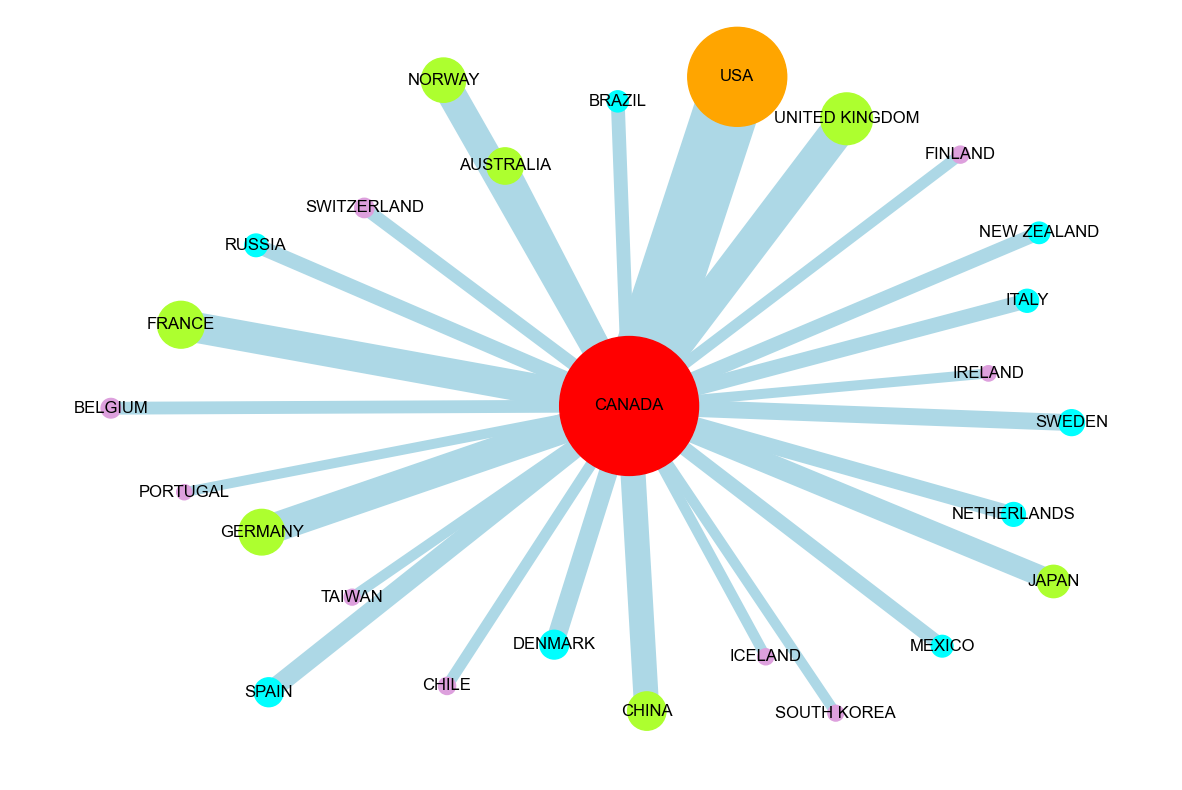

In [18]:
data = collaboration_df[(collaboration_df['collaborating_papers']>=50)].sort_values(by=['collaborator'])

g = nx.from_pandas_edgelist(df=data, source='main_country', target='collaborator',edge_attr=['collaborating_papers','perc']) 

durations = [i['collaborating_papers'] for i in dict(g.edges).values()]

nodesize = [i['perc'] for i in dict(g.edges).values()]

labels = [i for i in dict(g.nodes).keys()]

totpapers = data[['collaborator','perc']].drop_duplicates()
totpapers['coallaborator'] = pd.Categorical(totpapers.collaborator, categories = labels, ordered = True)
totpapers = totpapers.sort_values(by='collaborator')
d = totpapers.set_index('collaborator')['perc'].to_dict()
d_canada = ({"CANADA": 100}) 
d_canada.update(d)
    
labels = {i:i for i in dict(g.nodes).keys()}

nodesize = [i for i in dict(d_canada).values()]
nodesize=[v * 100 for v in d_canada.values()]

colors = []
for i in nodesize:
    if i ==10000:
        colors.append("red")
    elif 5000 < i < 10000:
        colors.append('orange')
    elif 2000 < i < 5000: 
        colors.append("yellow")
    elif 500 < i < 2000: 
        colors.append("greenyellow")
    elif 200 < i < 500: 
        colors.append("aqua")
    else: 
        colors.append('plum')
        
fig, ax = plt.subplots(figsize=(15,10))
pos = nx.spring_layout(g,k=0.7, iterations=19)
nx.draw_networkx_nodes(g, pos, ax = ax, node_color=colors,node_size=nodesize)
nx.draw_networkx_edges(g, pos, width=np.sqrt(durations), ax=ax,edge_color='lightblue')
_ = nx.draw_networkx_labels(g, pos, labels, ax=ax,font_size=12,font_color='black')
plt.axis('off')

plt.show()

## Conclusions

- Canada is the sixth largest producer of ocean research
- Yearly output has stagnated (around 450 papers) and now lower than Australia
- Canada has most papers covering the Atlantic but its largest share is in the Arctic, where it is the thid biggest contributor
- Fifty percent of Canada's collaboration is with the US

## NSERC potential funding calls

- Canadian Arctic research (increase output to become the leading contributor)
- Trade partner collaborations (increase collaborations with Norway, Australia or Japan to strengthen trade agreements and knowledge transfer)
- Lessen or remove funding for Indian or Southern ocean research (due to low contributions)